<a href="https://colab.research.google.com/github/junh-cryp/Download-/blob/main/machine_learning_cw1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd

# This will prompt you to select and upload your CSV file from your computer
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"Successfully uploaded: {filename}")

# Load it into pandas
df = pd.read_csv(filename)
print("Dataset loaded successfully! Total rows:", len(df))

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv
Successfully uploaded: WA_Fn-UseC_-Telco-Customer-Churn (1).csv
Dataset loaded successfully! Total rows: 7043


--- DATA QUALITY SUMMARY: MISSING VALUES ---


,Total Instances,Missing / Null Count (NaN),"Whitespace Count ("" "")",Data Type Before Cleaning,Data Type After Coercion
TotalCharges,7043,11,11,object,float64


Total missing/blank records found: 11
--- TABLE 3.0: DETAILED MISSING VALUE INSTANCES ---


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


/tmp/ipykernel_1497/224429786.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts_by_tenure.index, y=missing_counts_by_tenure.values, palette='Reds_d')


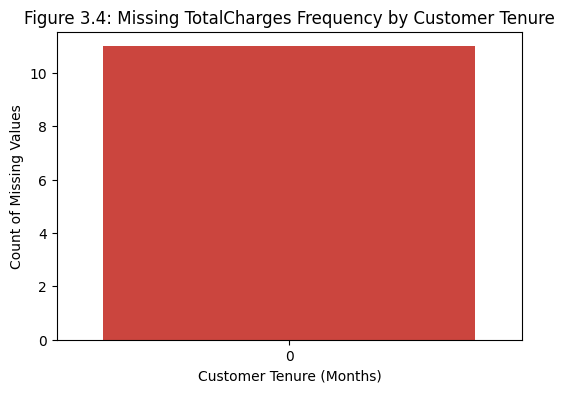

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Inspect missing values and blank spaces in TotalCharges
df['TotalCharges_clean'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Create a clean summary table of missing values
missing_df = pd.DataFrame({
    'Total Instances': len(df),
    'Missing / Null Count (NaN)': df['TotalCharges_clean'].isnull().sum(),
    'Whitespace Count (" ")': (df['TotalCharges'].str.strip() == '').sum(),
    'Data Type Before Cleaning': str(df['TotalCharges'].dtype),
    'Data Type After Coercion': str(df['TotalCharges_clean'].dtype)
}, index=['TotalCharges'])

# Display the summary table in Colab output
print("--- DATA QUALITY SUMMARY: MISSING VALUES ---")
display(missing_df)

# 1. Isolate and display the missing values table details
df['TotalCharges_clean'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_rows = df[df['TotalCharges_clean'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'Churn']]

print(f"Total missing/blank records found: {len(missing_rows)}")
print("--- TABLE 3.0: DETAILED MISSING VALUE INSTANCES ---")
display(missing_rows)

# 2. Generate a visual chart for Missing Values vs Tenure
plt.figure(figsize=(6, 4))
missing_counts_by_tenure = df[df['TotalCharges_clean'].isnull()]['tenure'].value_counts()
sns.barplot(x=missing_counts_by_tenure.index, y=missing_counts_by_tenure.values, palette='Reds_d')
plt.title('Figure 3.4: Missing TotalCharges Frequency by Customer Tenure')
plt.xlabel('Customer Tenure (Months)')
plt.ylabel('Count of Missing Values')
plt.savefig('missing_values_tenure.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges_clean'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Define numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges_clean']

# Generate statistical summary to check min, max, and percentiles for outliers
outlier_summary = df[num_cols].describe()
print("--- STATISTICAL SUMMARY FOR OUTLIER INSPECTION ---")
display(outlier_summary)

--- STATISTICAL SUMMARY FOR OUTLIER INSPECTION ---


,tenure,MonthlyCharges,TotalCharges_clean
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Check unique values and their frequencies for the Contract column
print("Unique Contract values:")
print(df['Contract'].value_counts())
print("Total Count:", df['Contract'].count())

Unique Contract values:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
Total Count: 7043


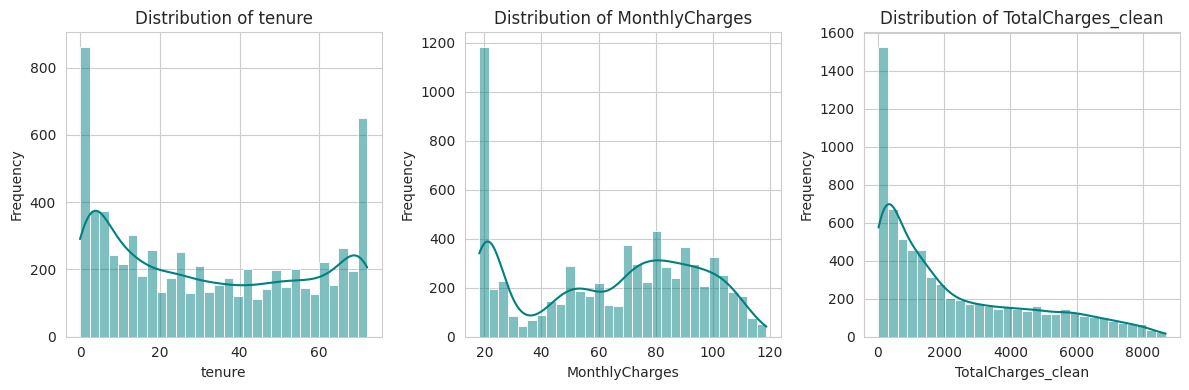

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset and clean TotalCharges
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges_clean'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Define numerical columns for distribution plotting
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges_clean']

# Set plot style
plt.figure(figsize=(12, 4))
sns.set_style("whitegrid")

# Plot histograms for each continuous numerical feature
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col].dropna(), kde=True, bins=30, color='teal')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

--- CLASS DISTRIBUTION SUMMARY ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_1497/469424559.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='Set2')


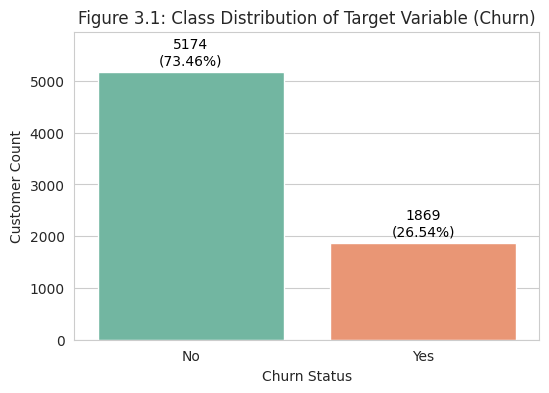

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Calculate class distribution counts and percentages
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("--- CLASS DISTRIBUTION SUMMARY ---")
print(churn_counts)
print(churn_percentages)

# Generate class imbalance bar plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Figure 3.1: Class Distribution of Target Variable (Churn)')
plt.xlabel('Churn Status')
plt.ylabel('Customer Count')

# Calculate total number of rows for percentage computation
total = len(df)

# Add data labels on top of bars showing count and percentage
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{int(height)}\n({percentage:.2f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 3),
                textcoords='offset points')

# Adjust y-axis limit slightly higher to make room for the two-line text labels
plt.ylim(0, max(churn_counts) * 1.15)

plt.savefig('class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Check for duplicate customerIDs
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())

Duplicate customerIDs: 0


--- 1. BASIC DATASET INFO ---
Total instances: 7043
Total attributes: 21

--- 2. MISSING VALUES IN TotalCharges ---
Number of missing/whitespace records: 11

--- 3. CLASS IMBALANCE (CHURN) ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

--- 4. STATISTICAL SUMMARIES & SKEWNESS ---
            tenure  MonthlyCharges  TotalCharges_clean
count  7043.000000     7043.000000         7032.000000
mean     32.371149       64.761692         2283.300441
std      24.559481       30.090047         2266.771362
min       0.000000       18.250000           18.800000
25%       9.000000       35.500000          401.450000
50%      29.000000       70.350000         1397.475000
75%      55.000000       89.850000         3794.737500
max      72.000000      118.750000         8684.800000

Skewness:
tenure                0.239540
MonthlyCharges       -0.220524
TotalCharges_clean    0.961642
dtype: float64


/tmp/ipykernel_600/3865889979.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='Set2')


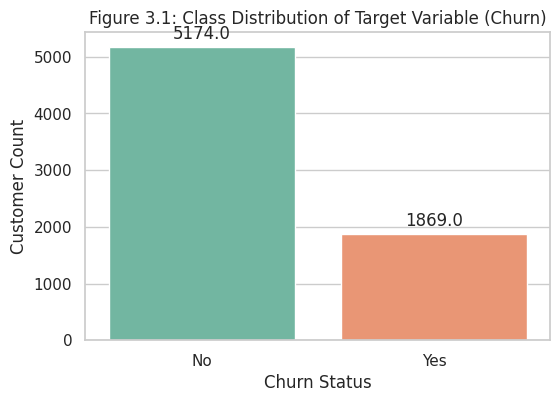

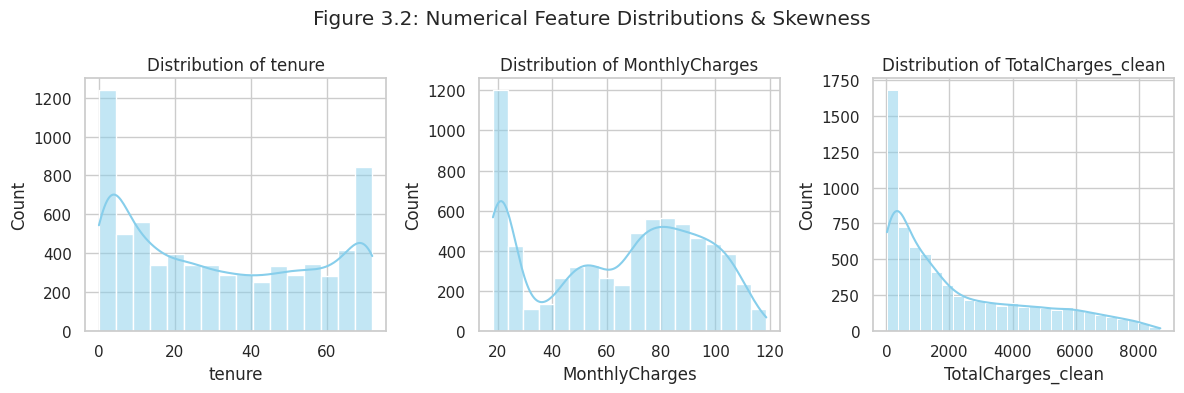

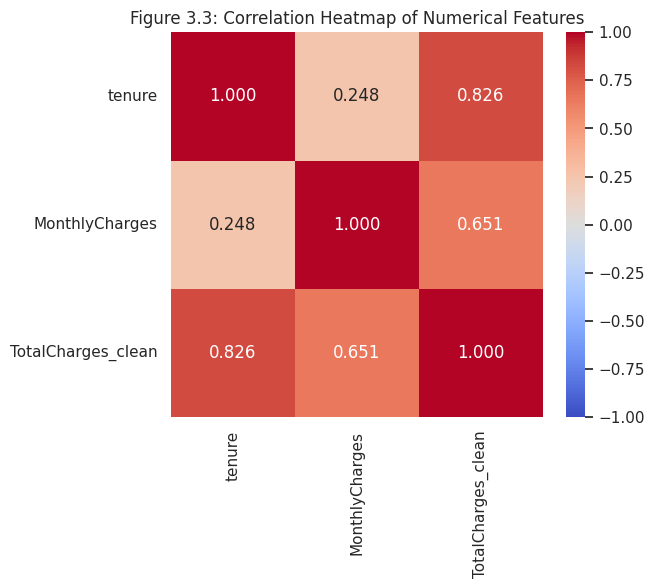

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("--- 1. BASIC DATASET INFO ---")
print("Total instances:", len(df))
print("Total attributes:", len(df.columns))

# 2. Missing Values / Whitespace check in TotalCharges
df['TotalCharges_clean'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_count = df['TotalCharges_clean'].isnull().sum()
print(f"\n--- 2. MISSING VALUES IN TotalCharges ---")
print(f"Number of missing/whitespace records: {missing_count}")

# 3. Class Imbalance Check
print(f"\n--- 3. CLASS IMBALANCE (CHURN) ---")
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(df['Churn'].value_counts(normalize=True) * 100)

# 4. Statistical Summary & Skewness
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges_clean']
print(f"\n--- 4. STATISTICAL SUMMARIES & SKEWNESS ---")
print(df[num_cols].describe())
print("\nSkewness:")
print(df[num_cols].skew())

# --- GENERATE VISUALISATIONS FOR REPORT FIGURES ---

# Figure 1: Class Imbalance Bar Chart
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Figure 3.1: Class Distribution of Target Variable (Churn)')
plt.xlabel('Churn Status')
plt.ylabel('Customer Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')
plt.savefig('class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Numerical Feature Distributions & Skewness (Histograms)
plt.figure(figsize=(12, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col].dropna(), kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.suptitle('Figure 3.2: Numerical Feature Distributions & Skewness')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: Correlation Heatmap (Multicollinearity)
plt.figure(figsize=(6, 5))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', vmin=-1, vmax=1)
plt.title('Figure 3.3: Correlation Heatmap of Numerical Features')
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()